# Probability and Statistics Fundamentals
### Interactive Notebook for AI/ML Interview Preparation

This notebook complements the **Probability_and_Statistics_Fundamentals.md** file.  
We'll explore key concepts through hands-on Python code, simulations, and visualizations.

**Topics Covered:**
1. Probability basics & simulations
2. Conditional probability & Bayes' theorem
3. Common probability distributions
4. Expectation, variance, covariance, correlation
5. Law of Large Numbers
6. Central Limit Theorem
7. PDF vs CDF

📺 **Video Lecture:** [https://youtu.be/T2v-1SwoTZQ](https://youtu.be/T2v-1SwoTZQ)

## Prerequisites & Setup

This notebook uses only standard Python scientific libraries.  
If any are missing, uncomment and run the install commands below.

In [1]:
# ── Prerequisites ──
# Uncomment below if you need to install any library:
# !pip install numpy matplotlib scipy seaborn pandas

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd

# Set consistent style for all plots
sns.set_style('whitegrid')
np.random.seed(42)  # For reproducibility

print('All libraries loaded successfully!')

All libraries loaded successfully!


---
## 1. Probability Basics — Coin Flips & Dice Rolls

**Key concept:** Probability is the long-run frequency of an event.  
We simulate experiments to see how empirical probability converges to the theoretical value.

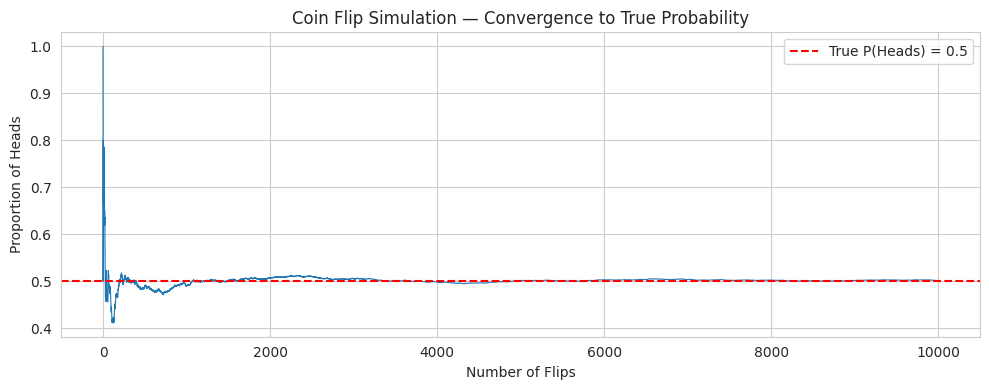

After 10000 flips: 5013 Heads, 4987 Tails
Empirical P(Heads) = 0.5013


In [2]:
# ── Simulating fair coin flips ──
# Theoretical probability of heads = 0.5

n_flips = 10000
flips = np.random.choice(['Heads', 'Tails'], size=n_flips)

# Track the running proportion of heads
cumulative_heads = np.cumsum(flips == 'Heads')
running_proportion = cumulative_heads / np.arange(1, n_flips + 1)

plt.figure(figsize=(10, 4))
plt.plot(running_proportion, linewidth=0.8)
plt.axhline(y=0.5, color='red', linestyle='--', label='True P(Heads) = 0.5')
plt.xlabel('Number of Flips')
plt.ylabel('Proportion of Heads')
plt.title('Coin Flip Simulation — Convergence to True Probability')
plt.legend()
plt.tight_layout()
plt.show()

print(f'After {n_flips} flips: {cumulative_heads[-1]} Heads, '
      f'{n_flips - cumulative_heads[-1]} Tails')
print(f'Empirical P(Heads) = {running_proportion[-1]:.4f}')

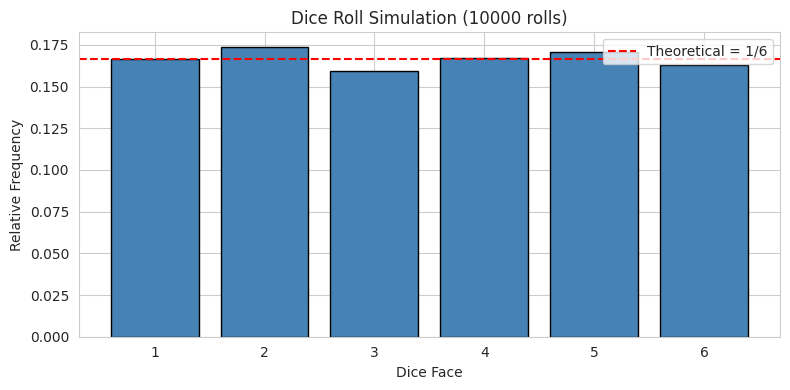

In [3]:
# ── Simulating dice rolls ──
# Theoretical probability of each face = 1/6 ≈ 0.1667

n_rolls = 10000
rolls = np.random.randint(1, 7, size=n_rolls)

# Count frequency of each face
faces, counts = np.unique(rolls, return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar(faces, counts / n_rolls, color='steelblue', edgecolor='black')
plt.axhline(y=1/6, color='red', linestyle='--', label='Theoretical = 1/6')
plt.xlabel('Dice Face')
plt.ylabel('Relative Frequency')
plt.title(f'Dice Roll Simulation ({n_rolls} rolls)')
plt.xticks(faces)
plt.legend()
plt.tight_layout()
plt.show()

---
## 2. Conditional Probability & Bayes' Theorem

**Bayes' Theorem:**  
$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

**Classic example:** A medical test for a rare disease.  
- Disease prevalence: 1%  
- Test sensitivity (true positive rate): 95%  
- Test specificity (true negative rate): 90%  

If a person tests positive, what is the probability they actually have the disease?

In [4]:
# ── Bayes' Theorem: Medical Test Example ──

prevalence = 0.01       # P(Disease) = 1%
sensitivity = 0.95      # P(Positive | Disease) = 95%
specificity = 0.90      # P(Negative | No Disease) = 90%

# P(Positive) = P(Pos|Disease)*P(Disease) + P(Pos|No Disease)*P(No Disease)
p_positive = sensitivity * prevalence + (1 - specificity) * (1 - prevalence)

# P(Disease | Positive) — applying Bayes' theorem
p_disease_given_positive = (sensitivity * prevalence) / p_positive

print('=== Bayes\' Theorem: Medical Test ===')
print(f'P(Disease)                = {prevalence:.2%}')
print(f'P(Positive | Disease)     = {sensitivity:.2%}')
print(f'P(Negative | No Disease)  = {specificity:.2%}')
print(f'P(Positive)               = {p_positive:.4f}')
print(f'\nP(Disease | Positive)     = {p_disease_given_positive:.2%}')
print(f'\n→ Even with a 95% sensitive test, a positive result only means')
print(f'  a {p_disease_given_positive:.1%} chance of disease when prevalence is low!')
print(f'  This is the base rate fallacy — a key interview concept.')

=== Bayes' Theorem: Medical Test ===
P(Disease)                = 1.00%
P(Positive | Disease)     = 95.00%
P(Negative | No Disease)  = 90.00%
P(Positive)               = 0.1085

P(Disease | Positive)     = 8.76%

→ Even with a 95% sensitive test, a positive result only means
  a 8.8% chance of disease when prevalence is low!
  This is the base rate fallacy — a key interview concept.


In [5]:
# ── Simulation: Verify Bayes' Theorem with 1 million people ──

n_people = 1_000_000
has_disease = np.random.rand(n_people) < prevalence

# Generate test results
test_positive = np.zeros(n_people, dtype=bool)
test_positive[has_disease] = np.random.rand(has_disease.sum()) < sensitivity
test_positive[~has_disease] = np.random.rand((~has_disease).sum()) < (1 - specificity)

# Empirical P(Disease | Positive)
positive_and_diseased = (test_positive & has_disease).sum()
total_positive = test_positive.sum()
empirical = positive_and_diseased / total_positive

print(f'Simulation with {n_people:,} people:')
print(f'  Truly diseased:        {has_disease.sum():,}')
print(f'  Tested positive:       {total_positive:,}')
print(f'  True positives:        {positive_and_diseased:,}')
print(f'  False positives:       {total_positive - positive_and_diseased:,}')
print(f'\n  Empirical P(Disease|Positive) = {empirical:.2%}')
print(f'  Theoretical (Bayes)           = {p_disease_given_positive:.2%}')

Simulation with 1,000,000 people:
  Truly diseased:        9,988
  Tested positive:       108,476
  True positives:        9,471
  False positives:       99,005

  Empirical P(Disease|Positive) = 8.73%
  Theoretical (Bayes)           = 8.76%


---
## 3. Common Probability Distributions

Understanding these distributions is essential for ML interviews:
- **Normal (Gaussian):** Continuous, bell-shaped — errors, natural measurements
- **Binomial:** Discrete — number of successes in n independent trials
- **Poisson:** Discrete — count of events in a fixed time/space interval
- **Exponential:** Continuous — time between Poisson events
- **Uniform:** Equal probability across a range

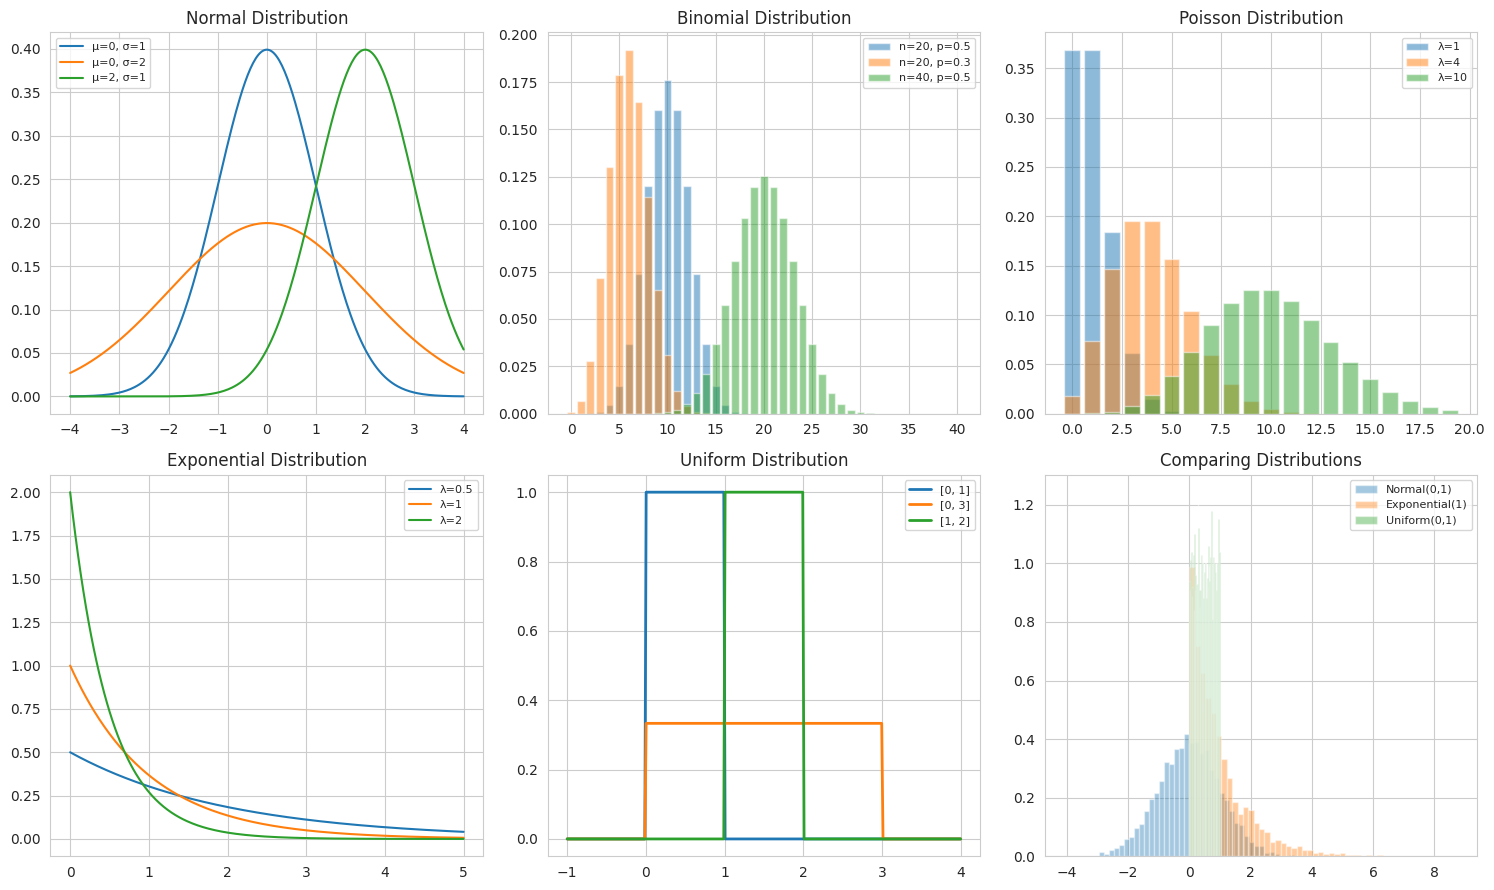

In [6]:
# ── Plotting 5 key distributions side by side ──

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# 1. Normal Distribution
x_norm = np.linspace(-4, 4, 300)
for mu, sigma in [(0, 1), (0, 2), (2, 1)]:
    axes[0, 0].plot(x_norm, stats.norm.pdf(x_norm, mu, sigma),
                    label=f'μ={mu}, σ={sigma}')
axes[0, 0].set_title('Normal Distribution')
axes[0, 0].legend(fontsize=8)

# 2. Binomial Distribution
for n, p in [(20, 0.5), (20, 0.3), (40, 0.5)]:
    x_binom = np.arange(0, n + 1)
    axes[0, 1].bar(x_binom, stats.binom.pmf(x_binom, n, p),
                   alpha=0.5, label=f'n={n}, p={p}')
axes[0, 1].set_title('Binomial Distribution')
axes[0, 1].legend(fontsize=8)

# 3. Poisson Distribution
for lam in [1, 4, 10]:
    x_pois = np.arange(0, 20)
    axes[0, 2].bar(x_pois, stats.poisson.pmf(x_pois, lam),
                   alpha=0.5, label=f'λ={lam}')
axes[0, 2].set_title('Poisson Distribution')
axes[0, 2].legend(fontsize=8)

# 4. Exponential Distribution
x_exp = np.linspace(0, 5, 300)
for lam in [0.5, 1, 2]:
    axes[1, 0].plot(x_exp, stats.expon.pdf(x_exp, scale=1/lam),
                    label=f'λ={lam}')
axes[1, 0].set_title('Exponential Distribution')
axes[1, 0].legend(fontsize=8)

# 5. Uniform Distribution
x_unif = np.linspace(-1, 4, 300)
for a, b in [(0, 1), (0, 3), (1, 2)]:
    axes[1, 1].plot(x_unif, stats.uniform.pdf(x_unif, a, b - a),
                    label=f'[{a}, {b}]', linewidth=2)
axes[1, 1].set_title('Uniform Distribution')
axes[1, 1].legend(fontsize=8)

# 6. Distribution comparison (samples)
samples = {
    'Normal(0,1)': np.random.normal(0, 1, 5000),
    'Exponential(1)': np.random.exponential(1, 5000),
    'Uniform(0,1)': np.random.uniform(0, 1, 5000)
}
for name, data in samples.items():
    axes[1, 2].hist(data, bins=50, alpha=0.4, density=True, label=name)
axes[1, 2].set_title('Comparing Distributions')
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 4. Expectation, Variance, Covariance & Correlation

| Measure | Formula | What it tells you |
|---|---|---|
| **Mean (E[X])** | Σxᵢ / n | Center of the distribution |
| **Variance (Var)** | E[(X - μ)²] | Spread of the distribution |
| **Covariance** | E[(X-μₓ)(Y-μᵧ)] | Direction of linear relationship |
| **Correlation** | Cov(X,Y) / (σₓ·σᵧ) | Strength & direction (scaled to [-1, 1]) |

In [7]:
# ── Compute statistics on sample data ──

# Generate correlated data
n = 500
x = np.random.normal(50, 10, n)           # e.g., hours studied
y = 2 * x + np.random.normal(0, 8, n)     # e.g., exam score (correlated with x)
z = np.random.normal(50, 10, n)            # e.g., shoe size (uncorrelated)

print('=== Descriptive Statistics ===')
print(f'X — Mean: {np.mean(x):.2f}, Variance: {np.var(x, ddof=1):.2f}, Std: {np.std(x, ddof=1):.2f}')
print(f'Y — Mean: {np.mean(y):.2f}, Variance: {np.var(y, ddof=1):.2f}, Std: {np.std(y, ddof=1):.2f}')
print(f'Z — Mean: {np.mean(z):.2f}, Variance: {np.var(z, ddof=1):.2f}, Std: {np.std(z, ddof=1):.2f}')

print(f'\n=== Covariance & Correlation ===')
print(f'Cov(X, Y)  = {np.cov(x, y)[0, 1]:.2f}   (positive — X and Y move together)')
print(f'Corr(X, Y) = {np.corrcoef(x, y)[0, 1]:.4f} (strong positive correlation)')
print(f'Cov(X, Z)  = {np.cov(x, z)[0, 1]:.2f}   (near zero — no relationship)')
print(f'Corr(X, Z) = {np.corrcoef(x, z)[0, 1]:.4f} (no correlation)')

=== Descriptive Statistics ===
X — Mean: 49.79, Variance: 116.06, Std: 10.77
Y — Mean: 99.69, Variance: 533.87, Std: 23.11
Z — Mean: 49.06, Variance: 95.27, Std: 9.76

=== Covariance & Correlation ===
Cov(X, Y)  = 233.49   (positive — X and Y move together)
Corr(X, Y) = 0.9380 (strong positive correlation)
Cov(X, Z)  = -4.51   (near zero — no relationship)
Corr(X, Z) = -0.0429 (no correlation)


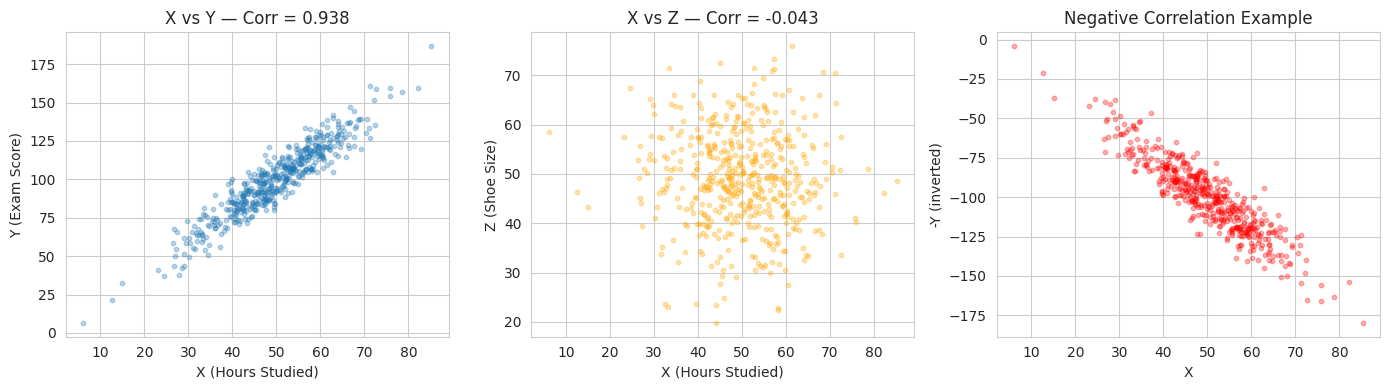

Interview tip: Correlation does NOT imply causation!
Correlation only measures LINEAR relationships — non-linear patterns may show Corr ≈ 0.


In [8]:
# ── Visualize correlation ──

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(x, y, alpha=0.3, s=10)
axes[0].set_title(f'X vs Y — Corr = {np.corrcoef(x, y)[0,1]:.3f}')
axes[0].set_xlabel('X (Hours Studied)')
axes[0].set_ylabel('Y (Exam Score)')

axes[1].scatter(x, z, alpha=0.3, s=10, color='orange')
axes[1].set_title(f'X vs Z — Corr = {np.corrcoef(x, z)[0,1]:.3f}')
axes[1].set_xlabel('X (Hours Studied)')
axes[1].set_ylabel('Z (Shoe Size)')

axes[2].scatter(x, -y + np.random.normal(0, 5, n), alpha=0.3, s=10, color='red')
axes[2].set_title('Negative Correlation Example')
axes[2].set_xlabel('X')
axes[2].set_ylabel('-Y (inverted)')

plt.tight_layout()
plt.show()

print('Interview tip: Correlation does NOT imply causation!')
print('Correlation only measures LINEAR relationships — non-linear patterns may show Corr ≈ 0.')

---
## 5. Law of Large Numbers (LLN)

**Statement:** As the sample size n → ∞, the sample mean converges to the population mean.  
$$\bar{X}_n \xrightarrow{P} \mu \text{ as } n \to \infty$$

This is why larger training datasets give better estimates of true patterns.

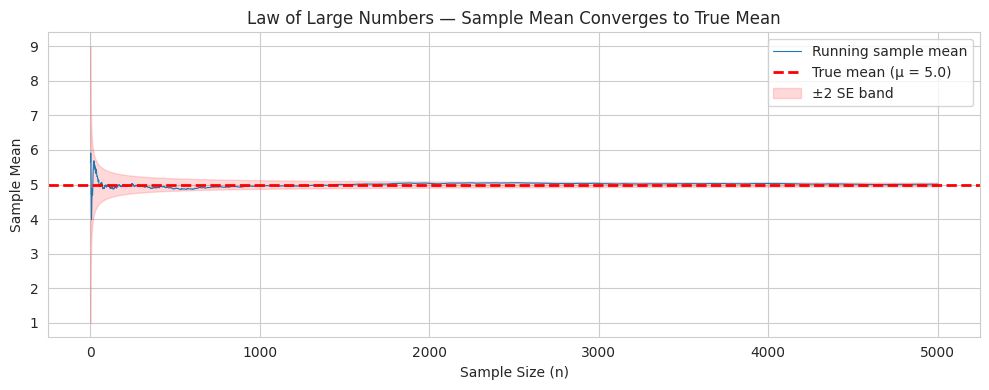

Sample mean at n=10:   4.741
Sample mean at n=100:  4.984
Sample mean at n=1000: 4.953
Sample mean at n=5000: 5.010
True mean:             5.0


In [9]:
# ── Law of Large Numbers: Sample mean converges to true mean ──

true_mean = 5.0
true_std = 2.0

sample_sizes = np.arange(1, 5001)
all_samples = np.random.normal(true_mean, true_std, size=5000)
running_means = np.cumsum(all_samples) / sample_sizes

plt.figure(figsize=(10, 4))
plt.plot(sample_sizes, running_means, linewidth=0.8, label='Running sample mean')
plt.axhline(y=true_mean, color='red', linestyle='--', linewidth=2,
            label=f'True mean (μ = {true_mean})')
plt.fill_between(sample_sizes,
                 true_mean - 2 * true_std / np.sqrt(sample_sizes),
                 true_mean + 2 * true_std / np.sqrt(sample_sizes),
                 alpha=0.15, color='red', label='±2 SE band')
plt.xlabel('Sample Size (n)')
plt.ylabel('Sample Mean')
plt.title('Law of Large Numbers — Sample Mean Converges to True Mean')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Sample mean at n=10:   {running_means[9]:.3f}')
print(f'Sample mean at n=100:  {running_means[99]:.3f}')
print(f'Sample mean at n=1000: {running_means[999]:.3f}')
print(f'Sample mean at n=5000: {running_means[4999]:.3f}')
print(f'True mean:             {true_mean}')

---
## 6. Central Limit Theorem (CLT)

**Statement:** Regardless of the population distribution, the distribution of sample means  
approaches a **Normal distribution** as sample size increases.

$$\bar{X}_n \sim N\left(\mu, \frac{\sigma^2}{n}\right) \text{ as } n \to \infty$$

This is one of the **most important theorems** in statistics and ML.  
It justifies using normal-based confidence intervals and hypothesis tests.

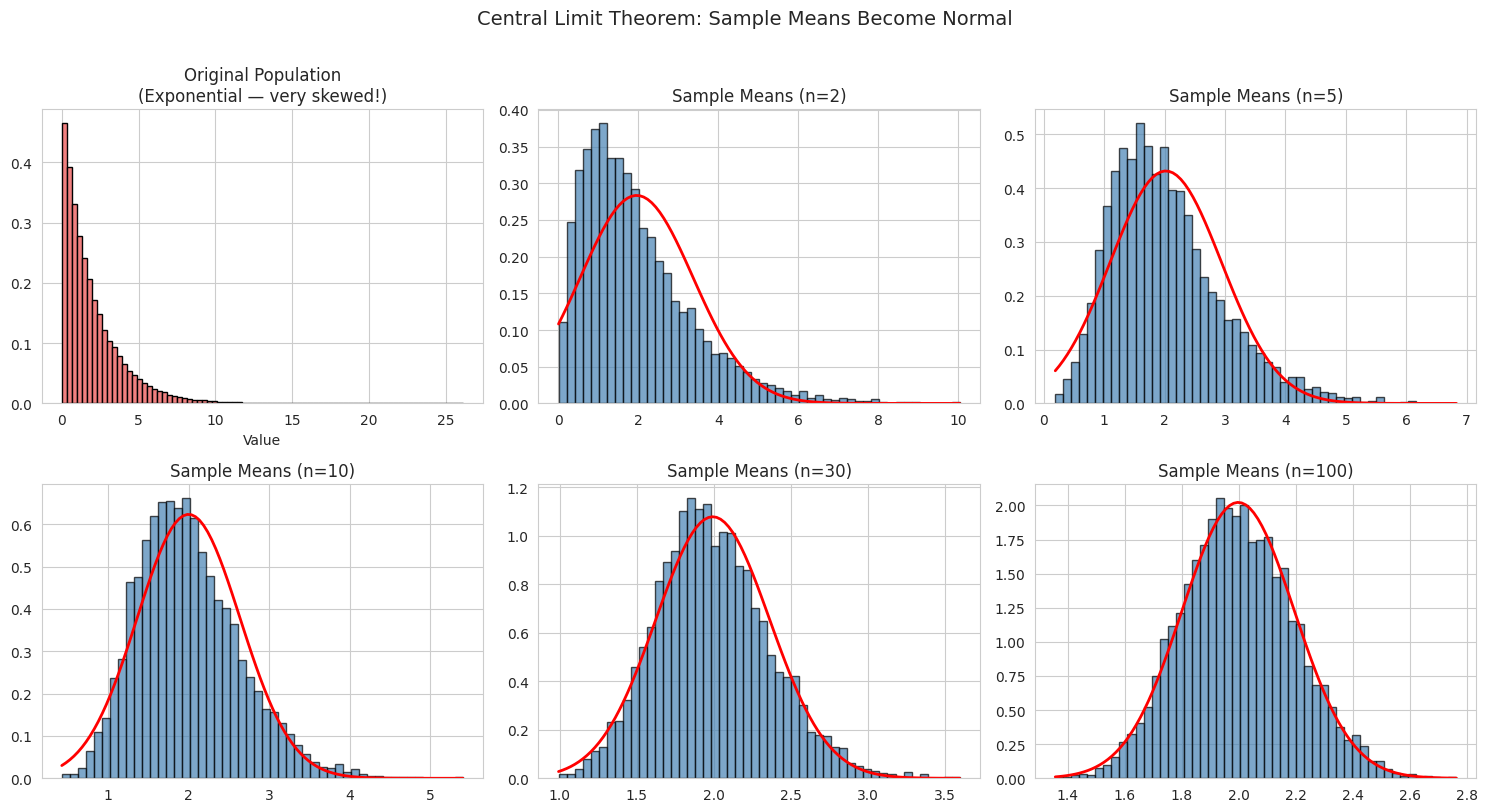

Key takeaway: Even from a skewed exponential population,
sample means look normal by n=30. This is the CLT in action!


In [10]:
# ── CLT Demonstration ──
# Take sample means from a VERY non-normal distribution (exponential)
# and show that the means become normally distributed

population = np.random.exponential(scale=2.0, size=100000)  # Skewed distribution

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Show the original (non-normal) population
axes[0, 0].hist(population, bins=80, density=True, color='lightcoral', edgecolor='black')
axes[0, 0].set_title('Original Population\n(Exponential — very skewed!)')
axes[0, 0].set_xlabel('Value')

# Show distribution of sample means for increasing n
sample_sizes_clt = [2, 5, 10, 30, 100]
n_experiments = 5000

for idx, n in enumerate(sample_sizes_clt):
    row, col = divmod(idx + 1, 3)
    # Draw n_experiments samples of size n, compute their means
    sample_means = [np.random.choice(population, size=n).mean()
                    for _ in range(n_experiments)]
    axes[row, col].hist(sample_means, bins=50, density=True,
                        color='steelblue', edgecolor='black', alpha=0.7)
    # Overlay theoretical normal
    x_range = np.linspace(min(sample_means), max(sample_means), 100)
    axes[row, col].plot(x_range,
                        stats.norm.pdf(x_range, np.mean(sample_means),
                                       np.std(sample_means)),
                        'r-', linewidth=2)
    axes[row, col].set_title(f'Sample Means (n={n})')

plt.suptitle('Central Limit Theorem: Sample Means Become Normal', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Key takeaway: Even from a skewed exponential population,')
print('sample means look normal by n=30. This is the CLT in action!')

---
## 7. PDF vs CDF

| | PDF (Probability Density Function) | CDF (Cumulative Distribution Function) |
|---|---|---|
| **What it shows** | Relative likelihood at each value | P(X ≤ x) — cumulative probability |
| **Y-axis** | Density (can exceed 1) | Probability [0, 1] |
| **Area under** | Total area = 1 | Always increases to 1 |
| **Use case** | Visualize distribution shape | Compute percentiles, compare distributions |

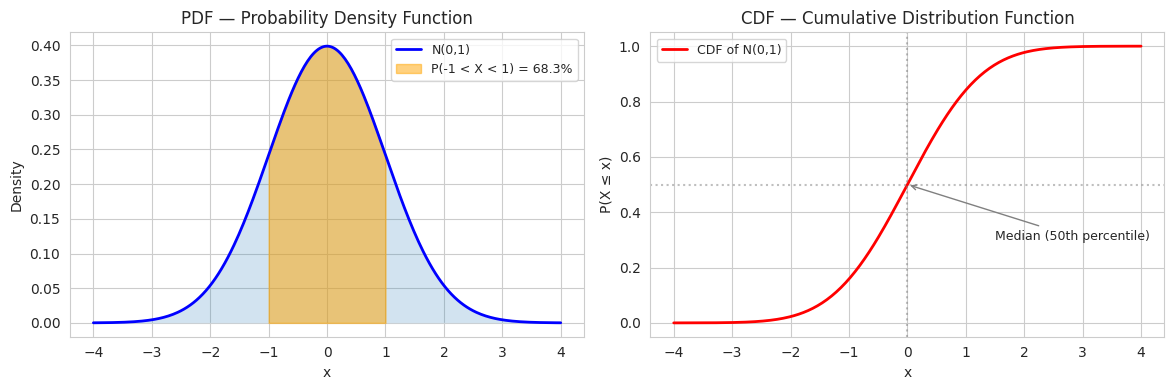

=== Practical CDF Calculations ===
P(X < 1.96)  = 0.9750  → 97.5th percentile
P(X < -1.96) = 0.0250  → 2.5th percentile
P(-1.96 < X < 1.96) = 0.9500 → 95% CI


In [11]:
# ── PDF vs CDF side by side ──

x = np.linspace(-4, 4, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PDF
axes[0].plot(x, stats.norm.pdf(x, 0, 1), 'b-', linewidth=2, label='N(0,1)')
axes[0].fill_between(x, stats.norm.pdf(x, 0, 1), alpha=0.2)
# Shade area for P(-1 < X < 1)
x_fill = np.linspace(-1, 1, 100)
axes[0].fill_between(x_fill, stats.norm.pdf(x_fill, 0, 1),
                     alpha=0.5, color='orange', label='P(-1 < X < 1) = 68.3%')
axes[0].set_title('PDF — Probability Density Function')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# CDF
axes[1].plot(x, stats.norm.cdf(x, 0, 1), 'r-', linewidth=2, label='CDF of N(0,1)')
axes[1].axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
axes[1].axvline(x=0, color='gray', linestyle=':', alpha=0.5)
axes[1].annotate('Median (50th percentile)', xy=(0, 0.5),
                 xytext=(1.5, 0.3), fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='gray'))
axes[1].set_title('CDF — Cumulative Distribution Function')
axes[1].set_ylabel('P(X ≤ x)')
axes[1].legend(fontsize=9)

for ax in axes:
    ax.set_xlabel('x')

plt.tight_layout()
plt.show()

# Practical use of CDF
print('=== Practical CDF Calculations ===')
print(f'P(X < 1.96)  = {stats.norm.cdf(1.96):.4f}  → 97.5th percentile')
print(f'P(X < -1.96) = {stats.norm.cdf(-1.96):.4f}  → 2.5th percentile')
print(f'P(-1.96 < X < 1.96) = {stats.norm.cdf(1.96) - stats.norm.cdf(-1.96):.4f} → 95% CI')

---
## 8. Conditional Probability — Simulation

**Conditional probability** P(A|B) is the probability of A given that B has occurred.  
$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

**Example:** Drawing cards — What is P(King | Face card)?

In [12]:
# ── Conditional Probability: Card Drawing ──

# A standard deck: 52 cards, 12 face cards (J, Q, K), 4 Kings
n_simulations = 100000

# Simulate drawing a random card
deck = list(range(52))  # 0-51
draws = np.random.choice(deck, size=n_simulations)

# Face cards: J=10, Q=11, K=12 in each suit → indices where rank >= 10
ranks = draws % 13  # 0=Ace, 1=2, ..., 10=J, 11=Q, 12=K
is_face = ranks >= 10   # J, Q, K
is_king = ranks == 12   # K

# P(King | Face card)
p_king_given_face = (is_king & is_face).sum() / is_face.sum()

print('=== Conditional Probability: Cards ===')
print(f'Total draws:          {n_simulations:,}')
print(f'Face cards drawn:     {is_face.sum():,}')
print(f'Kings drawn:          {is_king.sum():,}')
print(f'\nP(King | Face Card):')
print(f'  Empirical:    {p_king_given_face:.4f}')
print(f'  Theoretical:  {4/12:.4f}  (4 Kings out of 12 face cards)')

=== Conditional Probability: Cards ===
Total draws:          100,000
Face cards drawn:     22,895
Kings drawn:          7,609

P(King | Face Card):
  Empirical:    0.3323
  Theoretical:  0.3333  (4 Kings out of 12 face cards)


---
## Key Interview Takeaways

1. **Probability converges** — LLN ensures sample statistics approach true values with more data
2. **CLT is foundational** — it justifies normal-based methods even for non-normal data (n ≥ 30)
3. **Bayes' theorem** — always remember base rates; rare events + imperfect tests = many false positives
4. **Correlation ≠ Causation** — and correlation only captures *linear* relationships
5. **Know your distributions** — Normal for continuous errors, Binomial for binary trials, Poisson for counts, Exponential for waiting times
6. **PDF vs CDF** — PDF shows shape, CDF gives cumulative probabilities and percentiles

**Practice:** Try modifying the parameters in the code cells above (change sample sizes, distribution parameters, prevalence rates) to build intuition!

---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>